# 1. Preparação dos Dados 🛠️

## 1.1 Extração do arquivo tratado

In [2]:
import pandas as pd

caminho = '/content/churn_clientes.csv'

df = pd.read_csv(caminho)

df.head()

,ID_Cliente,Churn,Genero,Idoso,Possui_Parceiro,Possui_Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Servico_Internet,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Cobranca_Mensal,Cobranca_Total,Cobranca_Diaria
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


## 1.2 Remoção de Colunas Irrelevantes

In [3]:
# Removendo a coluna de Identificador Único
df = df.drop('ID_Cliente', axis=1)

print("Novo formato da base:", df.shape)
print("\nColunas Restantes:")
print(df.columns.tolist())

Novo formato da base: (7043, 21)

Colunas Restantes:
['Churn', 'Genero', 'Idoso', 'Possui_Parceiro', 'Possui_Dependentes', 'Meses_Contrato', 'Servico_Telefone', 'Multiplas_Linhas', 'Servico_Internet', 'Seguranca_Online', 'Backup_Online', 'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_TV', 'Streaming_Filmes', 'Tipo_Contrato', 'Fatura_Digital', 'Metodo_Pagamento', 'Cobranca_Mensal', 'Cobranca_Total', 'Cobranca_Diaria']


## 1.3 Encoding

In [4]:
# 1. Identificando quais colunas ainda são de texto (object)
colunas_categoricas = df.select_dtypes(include=['object']).columns.tolist()
print("Colunas que serão transformadas:", colunas_categoricas)

# 2. Aplicando o One-Hot Encoding
# O parâmetro dtype=int garante que os valores sejam 0 e 1 (ao invés de True e False)
df = pd.get_dummies(df, columns=colunas_categoricas, dtype=int)

# 3. Conferindo o resultado do Encoding
print("\nNovo formato da base:", df.shape)

df.head()

Colunas que serão transformadas: ['Genero', 'Servico_Internet', 'Tipo_Contrato', 'Metodo_Pagamento']

Novo formato da base: (7043, 29)


,Churn,Idoso,Possui_Parceiro,Possui_Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Seguranca_Online,Backup_Online,Protecao_Dispositivo,...,Servico_Internet_DSL,Servico_Internet_Fiber optic,Servico_Internet_No,Tipo_Contrato_Month-to-month,Tipo_Contrato_One year,Tipo_Contrato_Two year,Metodo_Pagamento_Bank transfer (automatic),Metodo_Pagamento_Credit card (automatic),Metodo_Pagamento_Electronic check,Metodo_Pagamento_Mailed check
0,0,0,1,1,9,1,0,0,1,0,...,1,0,0,0,1,0,0,0,0,1
1,0,0,0,0,9,1,1,0,0,0,...,1,0,0,1,0,0,0,0,0,1
2,1,0,0,0,4,1,0,0,0,1,...,0,1,0,1,0,0,0,0,1,0
3,1,1,1,0,13,1,0,0,1,1,...,0,1,0,1,0,0,0,0,1,0
4,1,1,1,0,3,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1


## 1.4 Verificação da Proporção de Evasão

In [5]:
# 1. Contagem absoluta de clientes que ficaram (0) e saíram (1)
contagem_classes = df['Churn'].value_counts()
print("--- Quantidade Absoluta por Classe ---")
print(contagem_classes)

# 2. Proporção em Porcentagem (usando normalize=True)
proporcao_classes = df['Churn'].value_counts(normalize=True) * 100
print("\n--- Proporção Percentual por Classe (%) ---")
print(proporcao_classes.round(2))

--- Quantidade Absoluta por Classe ---
Churn
0    5174
1    1869
Name: count, dtype: int64

--- Proporção Percentual por Classe (%) ---
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


## 1.5 Balanceamento de Classes

In [6]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. Separando as "Respostas" (y) das "Características" (X)
# X terá todas as colunas, exceto a coluna alvo
X = df.drop('Churn', axis=1)
# y terá apenas a coluna alvo (o que queremos prever)
y = df['Churn']

# 2. Dividindo os dados: 70% para Treino e 30% para Teste
# O 'stratify=y' garante que tanto o treino quanto o teste recebam a mesma
# proporção original de 73% não-evasão e 27% de evasão antes de mexermos.
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("--- Distribuição Original (Dados de Treino) ---")
print(y_treino.value_counts())

# 3. Aplicando o SMOTE APENAS nos dados de Treino
smote = SMOTE(random_state=42)
X_treino_balanceado, y_treino_balanceado = smote.fit_resample(X_treino, y_treino)

print("\n--- Distribuição Balanceada com SMOTE (Dados de Treino) ---")
print(y_treino_balanceado.value_counts())

--- Distribuição Original (Dados de Treino) ---
Churn
0    3622
1    1308
Name: count, dtype: int64

--- Distribuição Balanceada com SMOTE (Dados de Treino) ---
Churn
0    3622
1    3622
Name: count, dtype: int64


## 1.6 Normalização ou Padronização

In [7]:
from sklearn.preprocessing import StandardScaler

# 1. Separando apenas as colunas numéricas contínuas para padronizar
# (Não precisamos padronizar as colunas de 0 e 1 que criamos no Encoding)
colunas_numericas = ['Meses_Contrato', 'Cobranca_Mensal', 'Cobranca_Total', 'Cobranca_Diaria']

# 2. Inicializando o Padronizador
scaler = StandardScaler()

# 3. Ajustando (fit) o padronizador APENAS nos dados de treino balanceados
# e já transformando (transform) eles na mesma linha
X_treino_balanceado[colunas_numericas] = scaler.fit_transform(X_treino_balanceado[colunas_numericas])

# 4. Transformando os dados de teste usando a "régua" aprendida no treino
X_teste[colunas_numericas] = scaler.transform(X_teste[colunas_numericas])

# Visualizando como os dados ficaram após a padronização
print("--- Amostra dos Dados de Treino Padronizados ---")
display(X_treino_balanceado[colunas_numericas].head())

--- Amostra dos Dados de Treino Padronizados ---


,Meses_Contrato,Cobranca_Mensal,Cobranca_Total,Cobranca_Diaria
0,-0.561837,0.289952,-0.421427,0.291667
1,-0.937748,0.064714,-0.774647,0.061215
2,0.315289,0.246301,0.247565,0.249767
3,1.275951,0.626937,1.308990,0.626870
4,-1.063052,-0.647669,-0.881372,-0.651090


# 2. Correlação e Seleção de Variáveis 🎯

## 2.1 Análise de Correlação

/tmp/ipykernel_410/3454941570.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlacao_churn.values, y=correlacao_churn.index, palette='coolwarm')


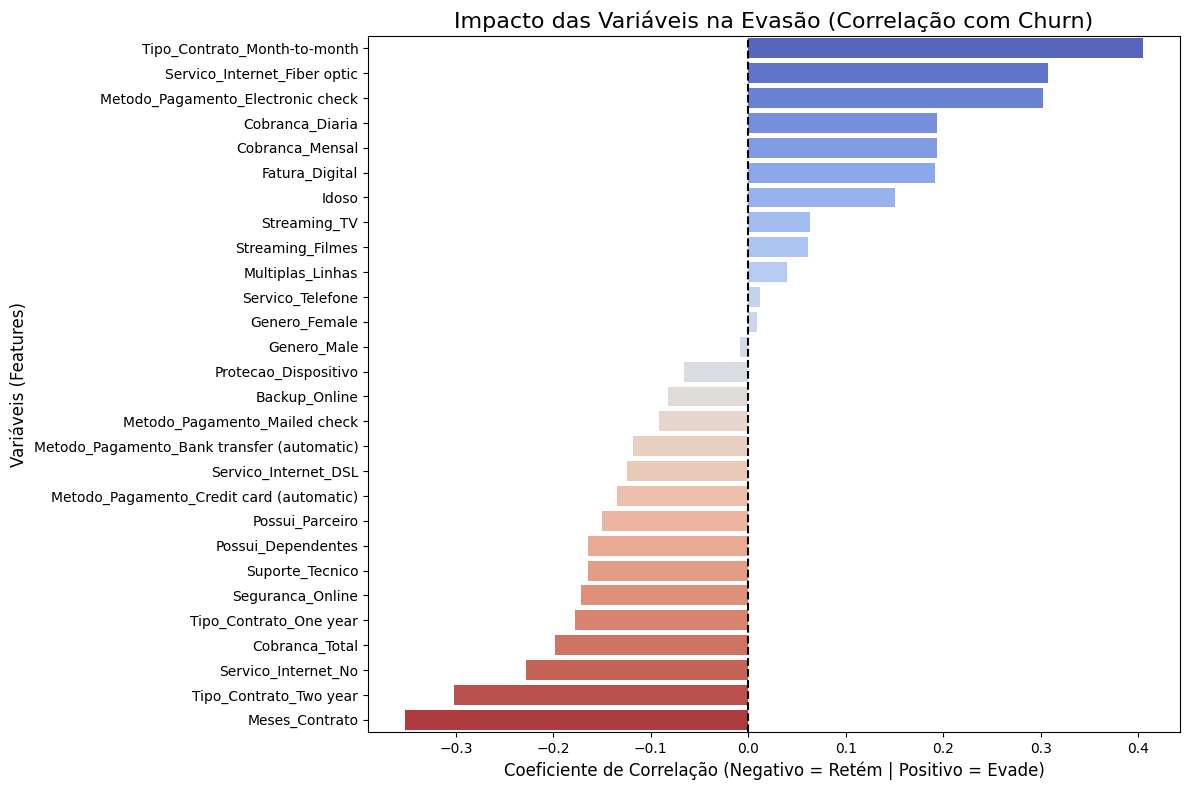

--- Top 5 Fatores que AUMENTAM a Evasão ---
Tipo_Contrato_Month-to-month         0.405103
Servico_Internet_Fiber optic         0.308020
Metodo_Pagamento_Electronic check    0.301919
Cobranca_Diaria                      0.193412
Cobranca_Mensal                      0.193356
Name: Churn, dtype: float64

--- Top 5 Fatores que REDUZEM a Evasão ---
Tipo_Contrato_One year   -0.177820
Cobranca_Total           -0.198324
Servico_Internet_No      -0.227890
Tipo_Contrato_Two year   -0.302253
Meses_Contrato           -0.352229
Name: Churn, dtype: float64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculando a matriz de correlação completa (método de Pearson)
# Utilizamos o DataFrame codificado com números (df)
matriz_correlacao = df.corr()

# 2. Isolando a correlação apenas da variável alvo ('Churn')
# e ordenando do maior para o menor
correlacao_churn = matriz_correlacao['Churn'].sort_values(ascending=False)

# Retirando o próprio 'Churn' (pois a correlação dele com ele mesmo é sempre 1)
correlacao_churn = correlacao_churn.drop('Churn')

# 3. Plotando um gráfico de barras focado no Churn
plt.figure(figsize=(12, 8))
sns.barplot(x=correlacao_churn.values, y=correlacao_churn.index, palette='coolwarm')

# Deixando o gráfico bonito
plt.title('Impacto das Variáveis na Evasão (Correlação com Churn)', fontsize=16)
plt.xlabel('Coeficiente de Correlação (Negativo = Retém | Positivo = Evade)', fontsize=12)
plt.ylabel('Variáveis (Features)', fontsize=12)

# Adicionando a linha do Zero
plt.axvline(x=0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

# Imprimindo os top valores no console para registro
print("--- Top 5 Fatores que AUMENTAM a Evasão ---")
print(correlacao_churn.head(5))
print("\n--- Top 5 Fatores que REDUZEM a Evasão ---")
print(correlacao_churn.tail(5))

plt.show()

## 2.2 Análises Direcionadas

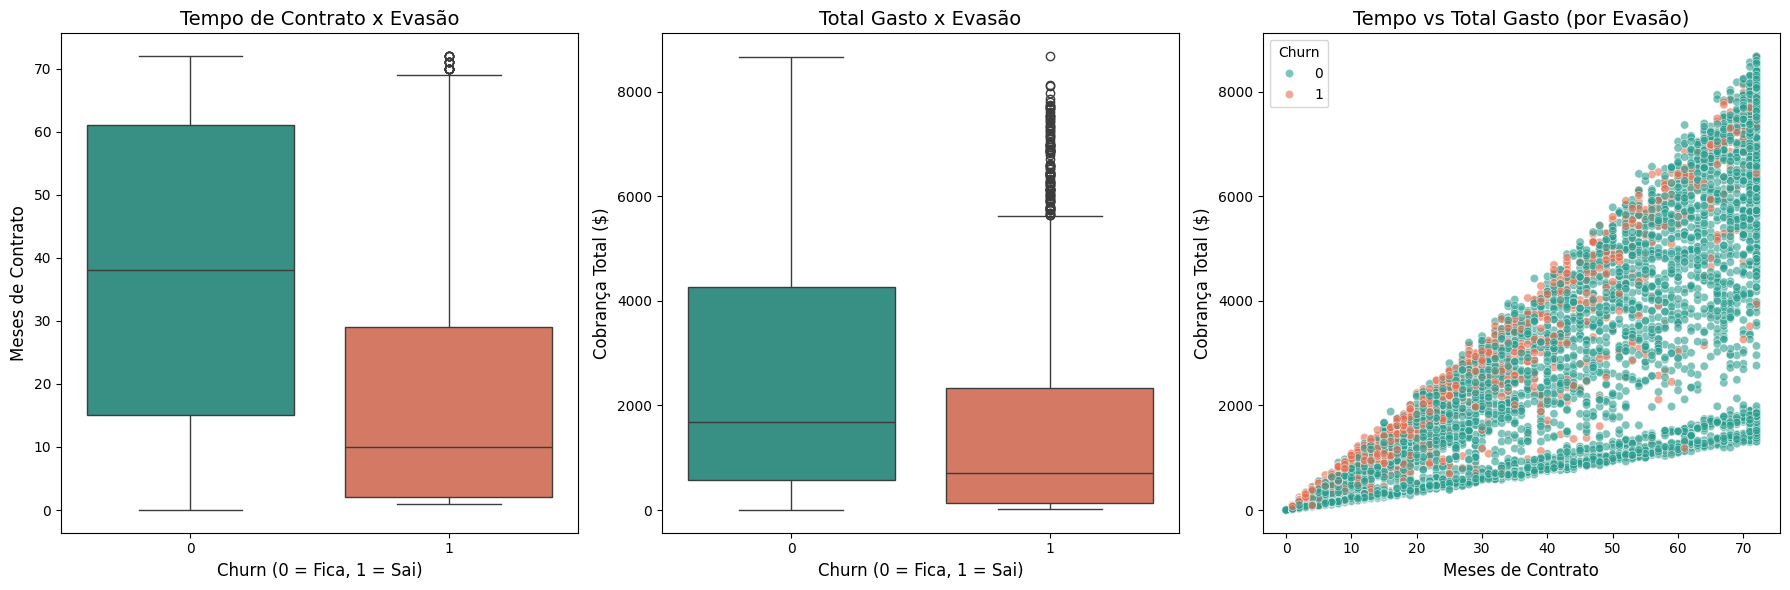

--- Medianas por Churn ---


,Meses_Contrato,Cobranca_Total
Churn,,
0,38.0,1679.525
1,10.0,703.550


In [9]:
# Configurando a área do gráfico (1 linha, 3 colunas)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Paleta de cores (Verde para quem Fica = 0, Vermelho para quem Sai = 1)
cores = ['#2a9d8f', '#e76f51']

# 1. Boxplot: Tempo de Contrato x Churn
sns.boxplot(data=df, x='Churn', y='Meses_Contrato', ax=axes[0], palette=cores, hue='Churn')
axes[0].set_title('Tempo de Contrato x Evasão', fontsize=14)
axes[0].set_xlabel('Churn (0 = Fica, 1 = Sai)', fontsize=12)
axes[0].set_ylabel('Meses de Contrato', fontsize=12)
axes[0].legend([],[], frameon=False) # Remove legenda duplicada

# 2. Boxplot: Total Gasto x Churn
sns.boxplot(data=df, x='Churn', y='Cobranca_Total', ax=axes[1], palette=cores, hue='Churn')
axes[1].set_title('Total Gasto x Evasão', fontsize=14)
axes[1].set_xlabel('Churn (0 = Fica, 1 = Sai)', fontsize=12)
axes[1].set_ylabel('Cobrança Total ($)', fontsize=12)
axes[1].legend([],[], frameon=False)

# 3. Scatter plot (Gráfico de Dispersão): Tempo vs Total Gasto
sns.scatterplot(data=df, x='Meses_Contrato', y='Cobranca_Total', hue='Churn', palette=cores, alpha=0.6, ax=axes[2])
axes[2].set_title('Tempo vs Total Gasto (por Evasão)', fontsize=14)
axes[2].set_xlabel('Meses de Contrato', fontsize=12)
axes[2].set_ylabel('Cobrança Total ($)', fontsize=12)

# Ajuste visual
plt.tight_layout()
plt.show()

# Resumo em números para a apresentação
print("--- Medianas por Churn ---")
display(df.groupby('Churn')[['Meses_Contrato', 'Cobranca_Total']].median())

# 3. Modelagem Preditiva 🤖

## 3.1 Separação de Dados

In [10]:
from sklearn.model_selection import train_test_split

# 1. Separando o que queremos prever (y = Variável Alvo) do restante (X = Características/Features)
# O eixo X terá todas as colunas, exceto a coluna Churn
X = df.drop('Churn', axis=1)

# O eixo y terá EXCLUSIVAMENTE a coluna Churn
y = df['Churn']

# 2. Fazendo a divisão 70/30 (test_size=0.3)
# O random_state=42 garante que a divisão aleatória será sempre a mesma toda vez que rodarmos o código (reprodutibilidade)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Conferindo como ficaram as fatias
print("--- Tamanho das Fatias ---")
print(f"Base Original: {df.shape[0]} clientes")
print(f"Treino (70%): {X_treino.shape[0]} clientes")
print(f"Teste (30%): {X_teste.shape[0]} clientes")

# 4. Conferindo o Balanceamento (Stratify)
print("\n--- Proporção de Churn no Treino (%) ---")
print((y_treino.value_counts(normalize=True) * 100).round(2))

print("\n--- Proporção de Churn no Teste (%) ---")
print((y_teste.value_counts(normalize=True) * 100).round(2))

--- Tamanho das Fatias ---
Base Original: 7043 clientes
Treino (70%): 4930 clientes
Teste (30%): 2113 clientes

--- Proporção de Churn no Treino (%) ---
Churn
0    73.47
1    26.53
Name: proportion, dtype: float64

--- Proporção de Churn no Teste (%) ---
Churn
0    73.45
1    26.55
Name: proportion, dtype: float64


## 3.2 Criação de Modelos

Modelo 1: Regressão Logística (Logistic Regression)

Por que foi escolhido: É o modelo mais utilizado no mundo corporativo para problemas de sim/não (0 ou 1) porque ele é interpretável. Ele consegue nos dizer exatamente o peso de cada variável (ex: "O contrato mensal aumenta a chance de evasão em 40%").

Precisa de Normalização? SIM. A Regressão Logística funciona baseada em equações matemáticas lineares e cálculos de distância. Como temos a coluna Meses_Contrato (que vai até 72) e a coluna Cobranca_Total (que chega a 8.000), se não normalizarmos, a IA vai achar que a cobrança total é "mais importante" só porque o número é maior. A normalização (Padronização) coloca todas as variáveis na mesma escala, deixando o jogo justo.

In [11]:
from sklearn.linear_model import LogisticRegression

print("Iniciando a criação do modelo de Regressão Logística...")

# 1. Instanciando (Criando) o modelo
# max_iter=1000 garante que o modelo tenha tempo suficiente para encontrar os melhores pesos matemáticos
modelo_rl = LogisticRegression(random_state=42, max_iter=1000)

# 2. Treinando o modelo com os dados de treino (que já foram balanceados e normalizados)
modelo_rl.fit(X_treino_balanceado, y_treino_balanceado)

print("✅ Modelo de Regressão Logística criado e treinado com sucesso!")

Iniciando a criação do modelo de Regressão Logística...
✅ Modelo de Regressão Logística criado e treinado com sucesso!


Modelo 2: Floresta Aleatória (Random Forest)

Por que foi escolhido: É um dos algoritmos mais poderosos e robustos do Machine Learning. Ele funciona criando centenas de "Árvores de Decisão" diferentes e fazendo uma votação entre elas. Ele é excelente para achar padrões complexos e ocultos que a Regressão Logística não consegue ver.

Precisa de Normalização? NÃO. Modelos baseados em árvores funcionam fazendo "cortes" nos dados (Exemplo: "O cliente tem mais de 10 meses de contrato?"). Para a árvore, não importa se o número está na escala original de milhares ou se foi normalizado para 0 e 1; o ponto de corte será o mesmo. No entanto, passar dados normalizados para ele não prejudica em nada o seu desempenho, então podemos usar a mesma base de dados do modelo anterior por praticidade.

In [12]:
from sklearn.ensemble import RandomForestClassifier

print("Iniciando a criação do modelo de Random Forest...")

# 1. Instanciando (Criando) o modelo
# n_estimators=100 indica que a "floresta" terá 100 árvores de decisão diferentes
# random_state=42 garante que o resultado será o mesmo toda vez que você rodar
modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100)

# 2. Treinando o modelo com os mesmos dados de treino
modelo_rf.fit(X_treino_balanceado, y_treino_balanceado)

print("✅ Modelo de Random Forest criado e treinado com sucesso!")

Iniciando a criação do modelo de Random Forest...
✅ Modelo de Random Forest criado e treinado com sucesso!


## 3.3 Avaliação dos Modelos

📊 Avaliando o Modelo de Regressão Logística...

--- MÉTRICAS DE DESEMPENHO ---
Acurácia:  0.2655
Precisão:  0.2655
Recall:    1.0000
F1-Score:  0.4196



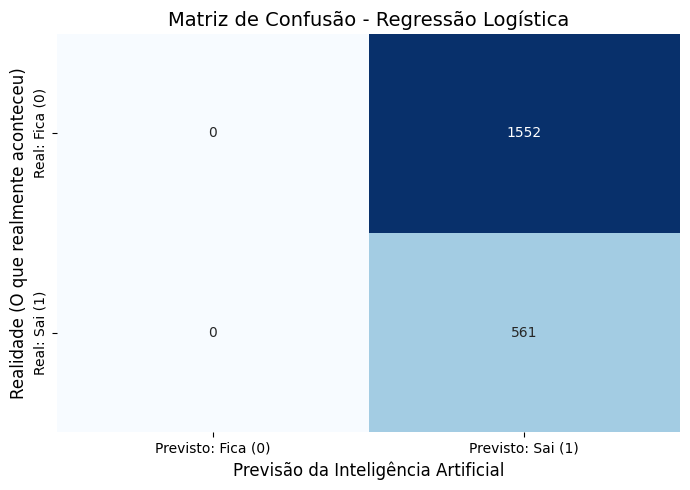

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("📊 Avaliando o Modelo de Regressão Logística...\n")

# 1. Fazendo as previsões com os dados de Teste (A "Prova Final")
# ATENÇÃO: Usamos o X_teste que foi separado lá atrás e que já passou pelo StandardScaler
y_pred_rl = modelo_rl.predict(X_teste)

# 2. Calculando as Métricas de Avaliação
acuracia_rl = accuracy_score(y_teste, y_pred_rl)
precisao_rl = precision_score(y_teste, y_pred_rl)
recall_rl = recall_score(y_teste, y_pred_rl)
f1_rl = f1_score(y_teste, y_pred_rl)

print("--- MÉTRICAS DE DESEMPENHO ---")
print(f"Acurácia:  {acuracia_rl:.4f}")
print(f"Precisão:  {precisao_rl:.4f}")
print(f"Recall:    {recall_rl:.4f}")
print(f"F1-Score:  {f1_rl:.4f}\n")

# 3. Gerando e Plotando a Matriz de Confusão
matriz_rl = confusion_matrix(y_teste, y_pred_rl)

plt.figure(figsize=(7, 5))
# Criando um mapa de calor (heatmap) para deixar a matriz bem visual
sns.heatmap(matriz_rl, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Previsto: Fica (0)', 'Previsto: Sai (1)'],
            yticklabels=['Real: Fica (0)', 'Real: Sai (1)'])

plt.title('Matriz de Confusão - Regressão Logística', fontsize=14)
plt.xlabel('Previsão da Inteligência Artificial', fontsize=12)
plt.ylabel('Realidade (O que realmente aconteceu)', fontsize=12)

plt.tight_layout()
plt.show()

📊 Avaliando o Modelo de Random Forest...

--- MÉTRICAS DE DESEMPENHO: RANDOM FOREST ---
Acurácia:  0.7549
Precisão:  0.5464
Recall:    0.4510
F1-Score:  0.4941



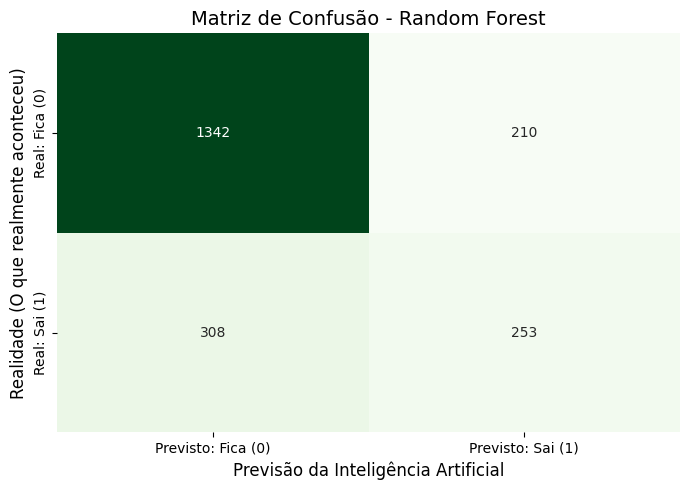

In [14]:
print("📊 Avaliando o Modelo de Random Forest...\n")

# 1. Fazendo as previsões com os dados de Teste
y_pred_rf = modelo_rf.predict(X_teste)

# 2. Calculando as Métricas
acuracia_rf = accuracy_score(y_teste, y_pred_rf)
precisao_rf = precision_score(y_teste, y_pred_rf)
recall_rf = recall_score(y_teste, y_pred_rf)
f1_rf = f1_score(y_teste, y_pred_rf)

print("--- MÉTRICAS DE DESEMPENHO: RANDOM FOREST ---")
print(f"Acurácia:  {acuracia_rf:.4f}")
print(f"Precisão:  {precisao_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}\n")

# 3. Gerando a Matriz de Confusão
matriz_rf = confusion_matrix(y_teste, y_pred_rf)

plt.figure(figsize=(7, 5))
# Usei a cor verde ('Greens') para diferenciar da Regressão Logística
sns.heatmap(matriz_rf, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Previsto: Fica (0)', 'Previsto: Sai (1)'],
            yticklabels=['Real: Fica (0)', 'Real: Sai (1)'])

plt.title('Matriz de Confusão - Random Forest', fontsize=14)
plt.xlabel('Previsão da Inteligência Artificial', fontsize=12)
plt.ylabel('Realidade (O que realmente aconteceu)', fontsize=12)

plt.tight_layout()
plt.show()

🏆 Qual modelo teve o melhor desempenho?
O grande vencedor é, sem dúvidas, o Random Forest (Floresta Aleatória).
Embora suas notas não sejam de 90% ou 100% (o que seria suspeito e irreal no mundo dos negócios), ele conseguiu equilibrar os acertos.

Acurácia (75,49%): Ele acertou o destino de 3 a cada 4 clientes da base de teste. Muito superior aos 26% da Regressão Logística.

F1-Score (0.4941): Mostra um equilíbrio razoável entre não dar falsos alarmes (Precisão de 54%) e conseguir capturar quem realmente vai sair (Recall de 45%).

⚠️ Análise de Overfitting e Underfitting


1. Regressão Logística (O Colapso / Underfitting Severo)

Diagnóstico: Sofreu um Underfitting gravíssimo. O modelo ficou simples demais e não conseguiu traçar uma "linha" matemática para separar quem fica de quem sai. Como resultado, ele "desistiu" de pensar e chutou que todos os clientes da prova iam cancelar (gerando o Recall de 100%, mas errando todo o resto).

Causas e Ajustes: A Regressão Logística é muito sensível. A combinação de criar dados falsos (SMOTE) com a mudança de escala (Normalização) distorceu os dados a ponto de confundir totalmente o algoritmo matemático. Ajuste sugerido: Tentar treiná-la sem o SMOTE ou ajustar o seu hiperparâmetro de regularização (C).

2. Random Forest (Leve Overfitting)

Diagnóstico: Árvores de decisão têm uma tendência natural a sofrer Overfitting (aprender demais sobre os dados de treino e acabar decorando os detalhes ao invés da regra geral). Como o nosso Recall foi de 45% nos dados de teste, isso indica que o modelo provavelmente foi perfeito no treino, mas teve um pouco de dificuldade de generalizar (encontrar os cancelamentos) quando viu clientes novos na "prova final".

Causas e Ajustes: O modelo que criamos permitiu que as árvores crescessem sem limites de profundidade. Ajuste sugerido: Para reduzir a complexidade e melhorar a generalização, poderíamos limitar a profundidade da árvore (parâmetro max_depth) ou aumentar o número mínimo de amostras por folha (min_samples_leaf).

# 4. Interpretação e Conclusões 📋

## 4.1 Análise de Importância das Variáveis

🔍 Analisando os Coeficientes da Regressão Logística...



/tmp/ipykernel_410/3281101904.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variavel', data=df_coeficientes, palette='coolwarm')


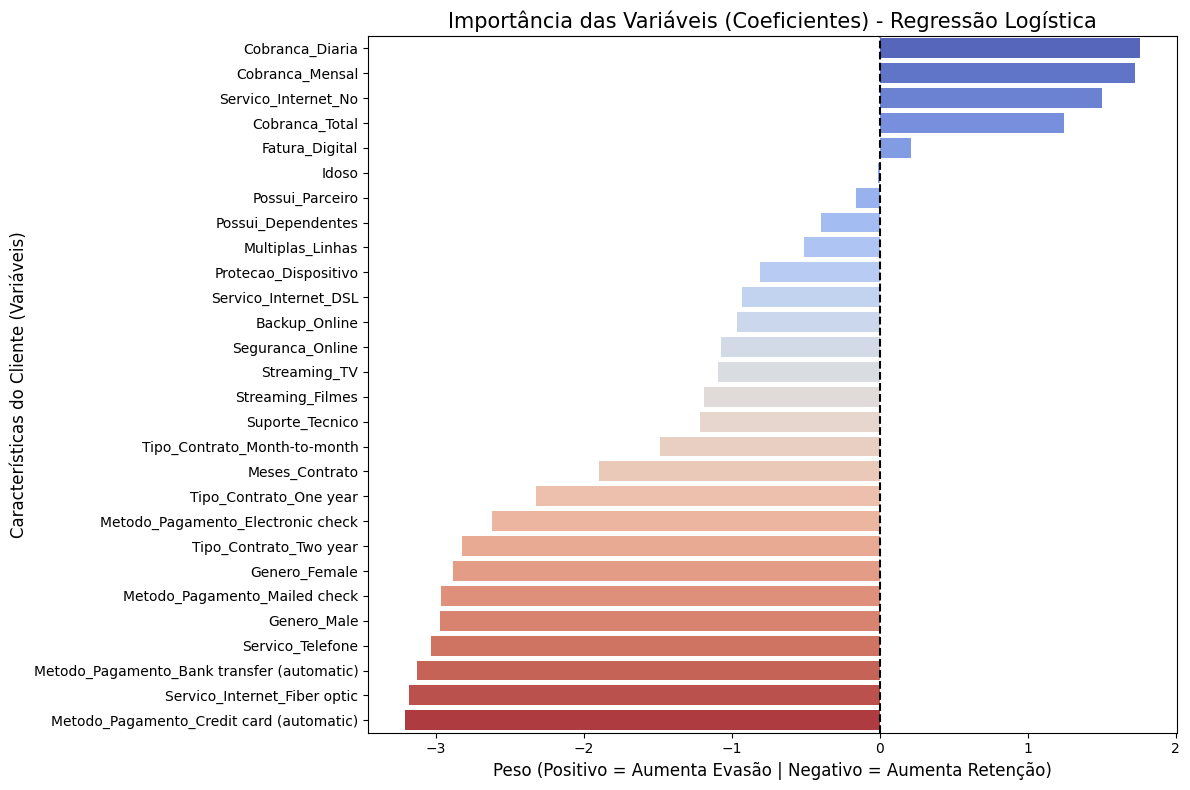

🚨 --- Top 5 Fatores que mais AUMENTAM a Evasão ---


,Variavel,Coeficiente
15,Cobranca_Diaria,1.758319
13,Cobranca_Mensal,1.725278
20,Servico_Internet_No,1.498852
14,Cobranca_Total,1.242732
12,Fatura_Digital,0.213265



🛡️ --- Top 5 Fatores que mais AJUDAM na Retenção ---


,Variavel,Coeficiente
17,Genero_Male,-2.974598
4,Servico_Telefone,-3.031556
24,Metodo_Pagamento_Bank transfer (automatic),-3.126036
19,Servico_Internet_Fiber optic,-3.178136
25,Metodo_Pagamento_Credit card (automatic),-3.209493


In [15]:
print("🔍 Analisando os Coeficientes da Regressão Logística...\n")

# 1. Extraindo os coeficientes do modelo treinado e os nomes das colunas originais
coeficientes_rl = modelo_rl.coef_[0]
nomes_variaveis = X.columns # O 'X' que separamos lá atrás tem os nomes de todas as colunas

# 2. Criando um DataFrame (Tabela) para organizar essas informações
df_coeficientes = pd.DataFrame({
    'Variavel': nomes_variaveis,
    'Coeficiente': coeficientes_rl
})

# Ordenando do maior peso positivo para o maior peso negativo
df_coeficientes = df_coeficientes.sort_values(by='Coeficiente', ascending=False)

# 3. Plotando o Gráfico de Importância das Variáveis
plt.figure(figsize=(12, 8))
sns.barplot(x='Coeficiente', y='Variavel', data=df_coeficientes, palette='coolwarm')

# Ajustes visuais do gráfico
plt.title('Importância das Variáveis (Coeficientes) - Regressão Logística', fontsize=15)
plt.xlabel('Peso (Positivo = Aumenta Evasão | Negativo = Aumenta Retenção)', fontsize=12)
plt.ylabel('Características do Cliente (Variáveis)', fontsize=12)

# Adicionando uma linha preta no ZERO para separar o que é bom do que é ruim
plt.axvline(x=0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

# 4. Imprimindo o Top 5 Vilões e Heróis no console
print("🚨 --- Top 5 Fatores que mais AUMENTAM a Evasão ---")
display(df_coeficientes.head(5))

print("\n🛡️ --- Top 5 Fatores que mais AJUDAM na Retenção ---")
display(df_coeficientes.tail(5))

🌲 Analisando a Importância das Variáveis (Random Forest)...



/tmp/ipykernel_410/2026427080.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variavel', data=df_importancias, palette='viridis')


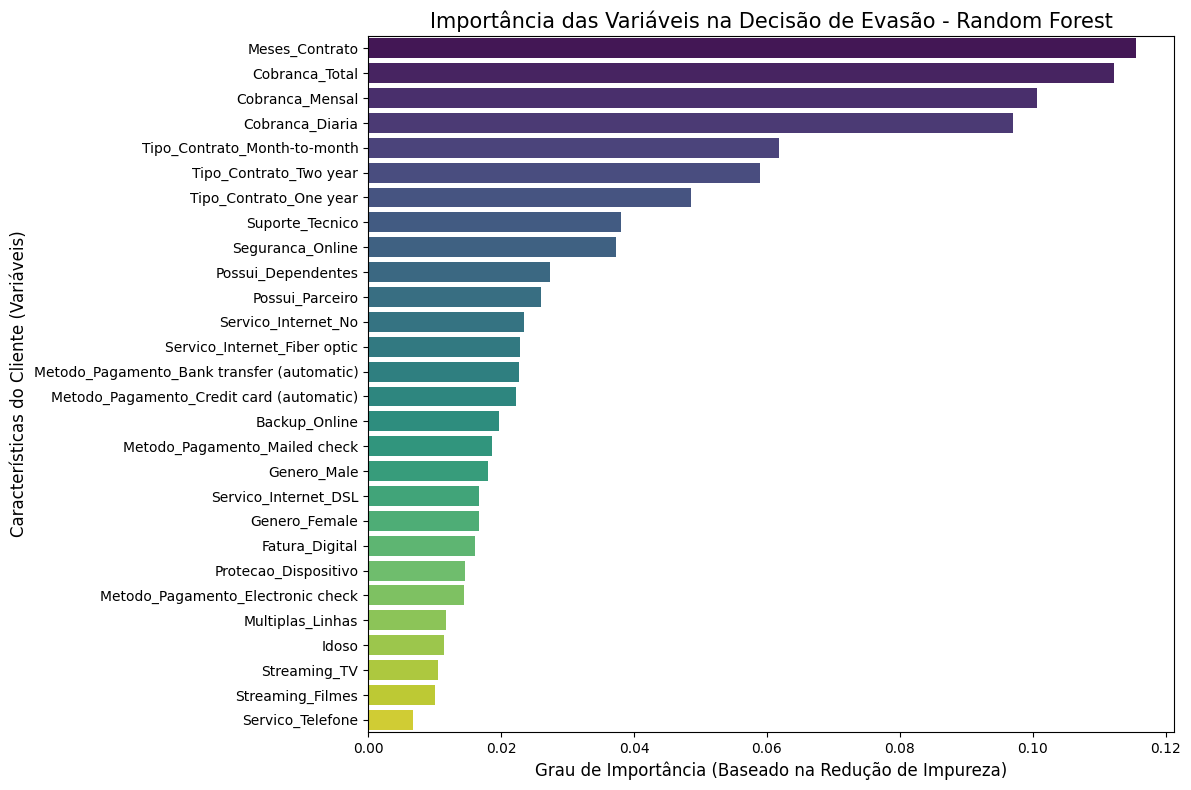

🏆 --- Top 10 Variáveis que mais influenciam a decisão da IA ---


,Variavel,Importancia
3,Meses_Contrato,0.115495
14,Cobranca_Total,0.112263
13,Cobranca_Mensal,0.100573
15,Cobranca_Diaria,0.096986
21,Tipo_Contrato_Month-to-month,0.061817
23,Tipo_Contrato_Two year,0.059010
22,Tipo_Contrato_One year,0.048574
9,Suporte_Tecnico,0.038028
6,Seguranca_Online,0.037280
2,Possui_Dependentes,0.027340


In [16]:
print("🌲 Analisando a Importância das Variáveis (Random Forest)...\n")

# 1. Extraindo a importância (feature_importances_) do modelo treinado
importancias_rf = modelo_rf.feature_importances_
nomes_variaveis = X.columns # Pegamos os nomes das colunas da nossa base original (X)

# 2. Criando um DataFrame (Tabela) para organizar o ranking
df_importancias = pd.DataFrame({
    'Variavel': nomes_variaveis,
    'Importancia': importancias_rf
})

# Ordenando da variável mais importante para a menos importante
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

# 3. Plotando o Gráfico de Importância
plt.figure(figsize=(12, 8))
# Usando a paleta 'viridis' que costuma ficar ótima para rankings
sns.barplot(x='Importancia', y='Variavel', data=df_importancias, palette='viridis')

# Ajustes visuais do gráfico
plt.title('Importância das Variáveis na Decisão de Evasão - Random Forest', fontsize=15)
plt.xlabel('Grau de Importância (Baseado na Redução de Impureza)', fontsize=12)
plt.ylabel('Características do Cliente (Variáveis)', fontsize=12)

plt.tight_layout()
plt.show()

# 4. Imprimindo o Top 10 no console
print("🏆 --- Top 10 Variáveis que mais influenciam a decisão da IA ---")
display(df_importancias.head(10))

## 4.2 Conclusão Estratégica e Recomendações de Negócio 📋🎯


Este projeto teve como objetivo desenvolver um pipeline de Machine Learning capaz de prever a evasão de clientes (Churn) da Telecom X e, mais importante, identificar as raízes desse problema para embasar ações de retenção.

## 1. Avaliação e Escolha do Modelo Preditivo 🤖
Durante a fase de modelagem, testamos duas abordagens distintas (Regressão Logística e Random Forest) utilizando dados balanceados artificialmente (SMOTE) e normalizados.

* **Regressão Logística:** O modelo sofreu um forte *underfitting*, falhando em capturar a complexidade dos dados após o balanceamento. Ele optou por prever que quase todos os clientes cancelariam, gerando um Recall de 100%, mas uma Precisão de apenas 26,5% (idêntica à taxa base de evasão).
* **Random Forest (O Vencedor):** O algoritmo de árvores de decisão lidou de forma muito mais inteligente com os dados. Ele entregou uma **Acurácia de 75,49%**, com um F1-Score equilibrado (~0.49). Ao identificar padrões complexos não-lineares, o Random Forest provou ser o modelo mais apto para ser colocado em produção na Telecom X.

---

## 2. O Raio-X da Evasão: Principais Fatores 🔍
Ao abrirmos a "caixa preta" do Random Forest (Feature Importance) e cruzarmos com os Coeficientes da Regressão Logística e a Análise de Correlação inicial, identificamos claramente que a decisão de evasão gravita em torno de 3 pilares principais:

1. **O Fator Financeiro (`Cobranca_Total` e `Cobranca_Mensal`):** São absolutos no topo da importância para a IA. Clientes com faturas mensais mais altas (mediana de $79) tendem a reavaliar constantemente o custo-benefício e cancelar o serviço.
2. **O Fator Risco / Flexibilidade (`Tipo_Contrato_Month-to-month`):** O contrato "mês a mês" é o maior gatilho isolado de evasão. Sem uma multa rescisória ou fidelidade, qualquer insatisfação resulta em cancelamento imediato.
3. **O Fator Lealdade (`Meses_Contrato`):** O primeiro ano é o "Vale da Morte". A mediana de tempo na empresa dos clientes que cancelam é de apenas 10 meses. Se o cliente sobrevive ao primeiro ano, a chance de evasão despenca.
4. **O Paradoxo do Produto (`Servico_Internet_Fiber optic`):** A internet de Fibra Ótica, que deveria ser o produto *premium*, aparece como um forte impulsionador de saídas, indicando uma falha grave na entrega de valor desse serviço específico.

---

## 3. Estratégias de Retenção Recomendadas 💡
Com base nas descobertas validadas pelos algoritmos de Machine Learning, recomendamos as seguintes estratégias para a diretoria da Telecom X:

* **Campanhas de Migração de Contrato (Upsell):** Criar promoções agressivas (ex: "Ganhe 2 meses grátis") para convencer os clientes do plano "Mês a Mês" a assinarem contratos de 1 ou 2 anos. A matemática prova que a fidelidade retém mais do que descontos pontuais.
* **Comitê de Qualidade da Fibra Ótica:** Iniciar imediatamente uma investigação técnica e comercial sobre a Fibra Ótica. O serviço está instável? O preço está muito acima dos concorrentes locais? Resolver o problema da Fibra salvará uma fatia massiva de clientes.
* **Programa de *Customer Success* nos Primeiros 10 Meses:** Implementar uma régua de relacionamento intensiva no primeiro ano do cliente. Ligar para oferecer suporte, checar a qualidade da internet e apresentar serviços extras de segurança online (que demonstraram reduzir a evasão).
* **Ofertas Preventivas (Usando a IA):** Integrar o modelo de Random Forest ao sistema de CRM. Sempre que a IA classificar um cliente com alto risco de Churn (Previsão = 1), o sistema deve gerar um alerta automático para a equipe de retenção oferecer um desconto ou upgrade antes mesmo do cliente pensar em ligar para cancelar.

---

## 4. Próximos Passos (Evolução Contínua) 🚀
Para o futuro da área de dados da Telecom X, os próximos passos envolvem:
1. **Otimização de Hiperparâmetros:** Utilizar *GridSearchCV* no Random Forest para calibrar a profundidade das árvores e melhorar a Precisão e o Recall.
2. **Teste de Novos Algoritmos:** Implementar modelos de Gradient Boosting (como XGBoost ou LightGBM), que costumam ser o "estado da arte" para dados tabulares desbalanceados.
3. **Deploy em Produção:** Criar uma API para que o modelo consuma dados reais todos os dias e alimente os painéis da equipe de retenção em tempo real.